# ResNet

Главная идея ResNet — shortcut connection, которая пропускает вход блока напрямую и добавляет его к результату свёрточной ветки. За счёт этого глубокие сети легче оптимизировать, и рост глубины перестаёт так быстро ломать обучение, как в “обычных” глубоких CNN.

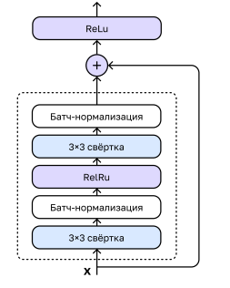

```
BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
```

In [1]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights, resnet50, ResNet50_Weights

# Что делать с моделью перед обучением?
- print(model) — понять структуру и где head.
- Выбрать, обучать с нуля или делать transfer learning с предобученными весами. (В большинстве реальных случаев лучше начинать с предобученных весов, а не с нуля.)

- Понять, какой вход ждёт модель и какой preprocessing нужен этим весам. (weights.transforms() — какой resize/crop/normalization рекомендуются под эти веса.)

- Заменить выходной слой под своё число классов. (model.fc.in_features — сколько признаков приходит в последний слой для ResNet.)

- Решить, какие слои замораживать, а какие учить. (Самый безопасный старт — заморозить backbone и обучать только новый классификатор сверху. Это особенно разумно, если датасет маленький, обучение нестабильно или нужно быстро проверить, вообще решается ли задача. Далее если модель недообучается или accuracy упирается слишком рано, разморозить layer4. Если всё ещё не хватает качества и данных достаточно, разморозь layer3 + layer4 или всю сеть.)

In [2]:
resnet_18 = resnet18(weights=ResNet18_Weights.DEFAULT)

print(resnet_18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s] 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
print(ResNet18_Weights.DEFAULT.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Предобработка входных изображений выполнялась в соответствии с ResNet18_Weights.DEFAULT.transforms(), поскольку этот пайплайн соответствует предобученным весам модели и обеспечивает корректную подготовку входных данных для инференса и валидации. Для тренировки также были добавлены аугментации.



In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(), 
                                       transforms.RandomRotation(10), transforms.ColorJitter(brightness=0.1, contrast=0.1), 
                                       transforms.ToTensor(), transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])
val_test_transforms = ResNet18_Weights.DEFAULT.transforms()

In [5]:
from torchvision import datasets
from torch.utils.data import Subset, DataLoader

torch.manual_seed(42)

indices = torch.randperm(20000).tolist()
split = int(0.8 * len(indices))

train_indices = indices[:split]
val_indices = indices[split:]

train_base = datasets.CIFAR10(root="../data/", train=True, transform=train_transforms, download=True)
val_base   = datasets.CIFAR10(root="../data/", train=True, transform=val_test_transforms, download=True)

train_dataset = Subset(train_base, train_indices)
val_dataset   = Subset(val_base, val_indices)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

100%|██████████| 170498071/170498071 [00:03<00:00, 50636757.07it/s]


Extracting ../data/cifar-10-python.tar.gz to ../data/
Files already downloaded and verified


In [6]:
test_dataset = datasets.CIFAR10(root='../data/', train=False, transform=val_test_transforms, download=True)

test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Files already downloaded and verified


Заморозим слои, которые не хотим переобучать.

In [7]:
# замораживаем все слои
for param in resnet_18.parameters():
    param.requires_grad = False
    
# учим только голову (будет обучаема по умолчанию)
resnet_18.fc = nn.Linear(resnet_18.fc.in_features, 10)

# разморозка 4-го слоя
for param in resnet_18.layer4.parameters():
    param.requires_grad = True

In [8]:
from torch import optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_18.parameters()), lr=0.0001)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_18.to(device)
print(device)

cuda


In [10]:
import copy

patience = 5
counter = 0
min_delta = 1e-4
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(resnet_18.state_dict())
num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    total_train_loss = 0
    total_val_loss = 0

    resnet_18.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out = resnet_18(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    resnet_18.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            out = resnet_18(images)
            loss = criterion(out, labels)
            total_val_loss += loss.item()
    
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_val_loss = total_val_loss / len(val_dataloader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]: Training Loss: {avg_train_loss:.4f} - Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(resnet_18.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

resnet_18.load_state_dict(best_model_wts)

Epoch [1/5]: Training Loss: 1.1686 - Validation Loss: 0.4793
Epoch [2/5]: Training Loss: 0.9476 - Validation Loss: 0.4146
Epoch [3/5]: Training Loss: 0.8716 - Validation Loss: 0.3515
Epoch [4/5]: Training Loss: 0.8338 - Validation Loss: 0.3403
Epoch [5/5]: Training Loss: 0.7969 - Validation Loss: 0.3504


<All keys matched successfully>

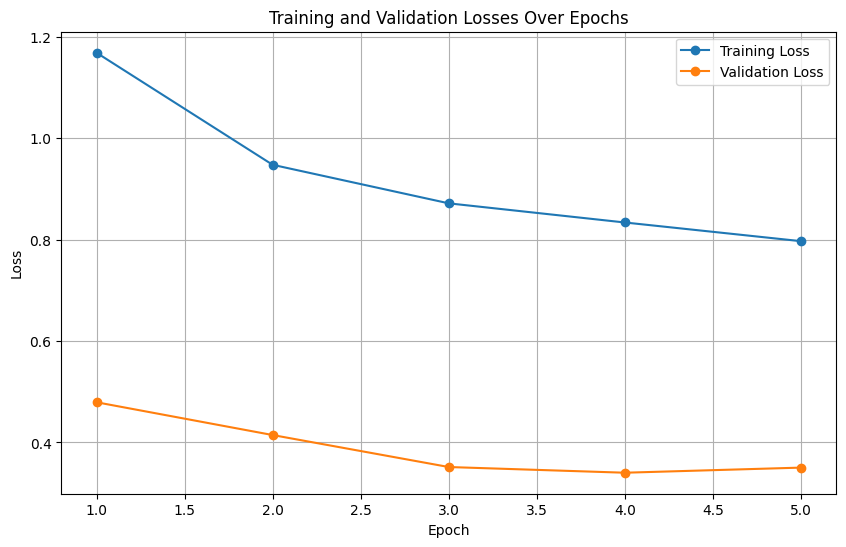

In [11]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import torch.nn.functional as F
test_pred_probs = []
test_pred_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        out = resnet_18(images)
        probs = F.softmax(out, dim=1)
        label = torch.argmax(out, dim=1)

        test_pred_probs.extend(probs.cpu().numpy())
        test_pred_labels.extend(label.cpu().numpy())

In [13]:
from sklearn.metrics import classification_report

test_labels = test_dataset.targets
cifar10_classes = test_dataset.classes
report = classification_report(test_labels, test_pred_labels, target_names=cifar10_classes)

print(report)

              precision    recall  f1-score   support

    airplane       0.87      0.88      0.88      1000
  automobile       0.94      0.94      0.94      1000
        bird       0.85      0.85      0.85      1000
         cat       0.82      0.72      0.77      1000
        deer       0.84      0.90      0.87      1000
         dog       0.85      0.81      0.83      1000
        frog       0.93      0.90      0.91      1000
       horse       0.87      0.94      0.90      1000
        ship       0.90      0.93      0.91      1000
       truck       0.93      0.93      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



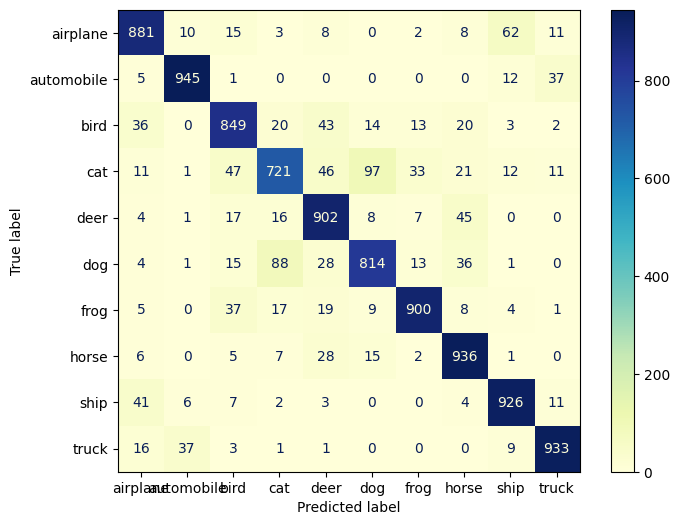

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(test_labels, test_pred_labels)

fig, ax = plt.subplots(figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix, display_labels=cifar10_classes)

display.plot(ax=ax, cmap='YlGnBu')

B ResNet50 вместо BasicBlock исполбзуется BottleNeck, потому что для более глубокой сети такой блок вычислительно выгоднее и позволяет наращивать глубину без слишком резкого роста числа параметров и вычислений. Оба блока остаются residual-блоками с shortcut-соединением, но их внутренняя структура отличается.

                           ↑
                        ReLU
                           ↑
                         (+)
                        ↗   ↖
                       /     \
                      /       \
        ┌───────────────────────────────┐
        │       Батч-нормализация       │
        │              ↑                │
        │          1×1 свёртка          │   ← расширение каналов
        │              ↑                │
        │             ReLU              │
        │              ↑                │
        │       Батч-нормализация       │
        │              ↑                │
        │          3×3 свёртка          │
        │              ↑                │
        │             ReLU              │
        │              ↑                │
        │       Батч-нормализация       │
        │              ↑                │
        │          1×1 свёртка          │   ← сжатие каналов
        └───────────────────────────────┘
                      ↑
                      x
                      │
                      └──────── shortcut ────────→


In [16]:
resnet_50 = resnet50(weights=ResNet50_Weights.DEFAULT)

print(resnet_50)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
print(ResNet50_Weights.DEFAULT.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [19]:
val_test_transforms = ResNet50_Weights.DEFAULT.transforms()

In [20]:
torch.manual_seed(42)

indices = torch.randperm(20000).tolist()
split = int(0.8 * len(indices))

train_indices = indices[:split]
val_indices = indices[split:]

train_base = datasets.CIFAR10(root="../data/", train=True, transform=train_transforms, download=True)
val_base   = datasets.CIFAR10(root="../data/", train=True, transform=val_test_transforms, download=True)

train_dataset = Subset(train_base, train_indices)
val_dataset   = Subset(val_base, val_indices)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

Files already downloaded and verified
Files already downloaded and verified


In [21]:
test_dataset = datasets.CIFAR10(root='../data/', train=False, transform=val_test_transforms, download=True)

test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Files already downloaded and verified


In [22]:
for param in resnet_50.parameters():
    param.requires_grad = False
    
resnet_50.fc = nn.Linear(resnet_50.fc.in_features, 10)

# разморозка 4-го слоя
for param in resnet_50.layer4.parameters():
    param.requires_grad = True

In [23]:
from torch import optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet_50.parameters()), lr=0.0001)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_50.to(device)
print(device)

cuda


In [25]:
min_delta = 1e-4
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(resnet_50.state_dict())
num_epochs = 5

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    total_train_loss = 0
    total_val_loss = 0

    resnet_50.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out = resnet_50(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)

    resnet_50.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            out = resnet_50(images)
            loss = criterion(out, labels)
            total_val_loss += loss.item() * images.size(0)
    
    avg_train_loss = total_train_loss / len(train_dataloader.dataset)
    avg_val_loss = total_val_loss / len(val_dataloader.dataset)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]: Training Loss: {avg_train_loss:.4f} - Validation Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(resnet_50.state_dict())

resnet_50.load_state_dict(best_model_wts)

Epoch [1/5]: Training Loss: 1.2965 - Validation Loss: 0.4328
Epoch [2/5]: Training Loss: 0.9894 - Validation Loss: 0.3902
Epoch [3/5]: Training Loss: 0.9036 - Validation Loss: 0.3237
Epoch [4/5]: Training Loss: 0.8342 - Validation Loss: 0.3347
Epoch [5/5]: Training Loss: 0.8084 - Validation Loss: 0.2947


<All keys matched successfully>

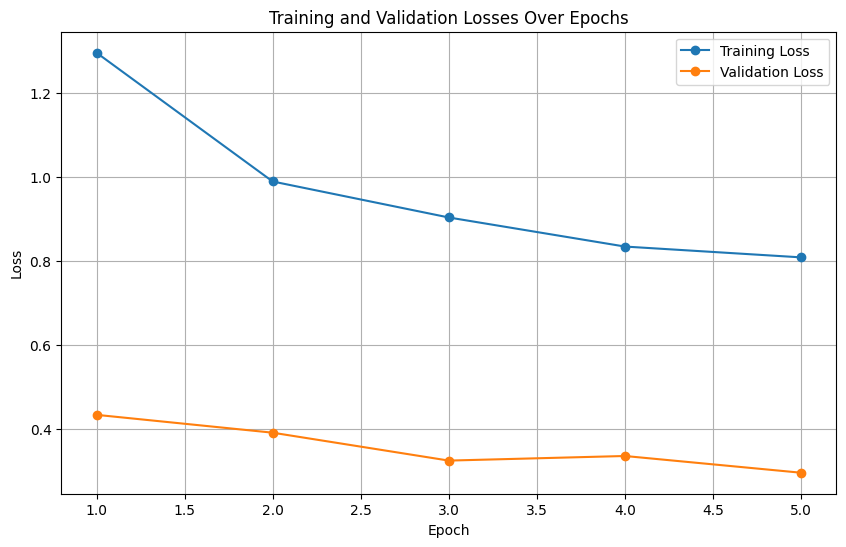

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label='Training Loss', marker='o')
plt.plot(epochs, val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
import torch.nn.functional as F
test_pred_probs = []
test_pred_labels = []

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        out = resnet_50(images)
        probs = F.softmax(out, dim=1)
        label = torch.argmax(out, dim=1)

        test_pred_probs.extend(probs.cpu().numpy())
        test_pred_labels.extend(label.cpu().numpy())

In [28]:
from sklearn.metrics import classification_report

test_labels = test_dataset.targets
cifar10_classes = test_dataset.classes
report = classification_report(test_labels, test_pred_labels, target_names=cifar10_classes)

print(report)

              precision    recall  f1-score   support

    airplane       0.93      0.89      0.91      1000
  automobile       0.96      0.94      0.95      1000
        bird       0.90      0.86      0.88      1000
         cat       0.80      0.85      0.82      1000
        deer       0.93      0.86      0.89      1000
         dog       0.86      0.87      0.86      1000
        frog       0.88      0.97      0.92      1000
       horse       0.93      0.90      0.92      1000
        ship       0.92      0.95      0.94      1000
       truck       0.94      0.94      0.94      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



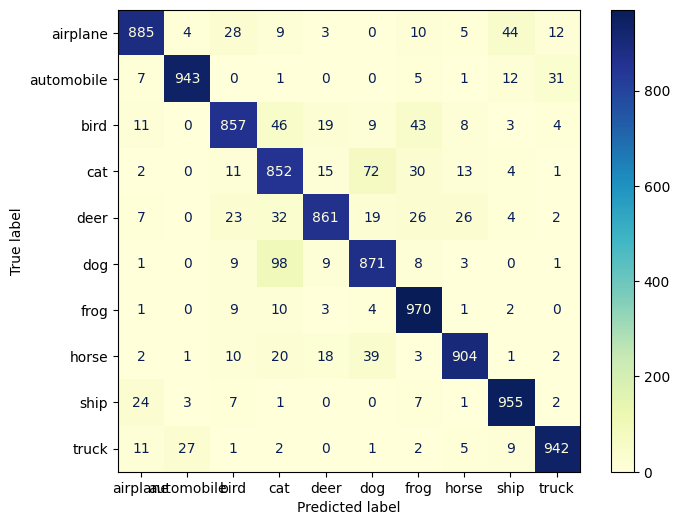

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

conf_matrix = confusion_matrix(test_labels, test_pred_labels)

fig, ax = plt.subplots(figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix, display_labels=cifar10_classes)

display.plot(ax=ax, cmap='YlGnBu')